In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("CH.SC.U4CSE24156_EX-8.6_1(SVM).csv")

data.head()

,X,Quadratic_Value,Class
0,-5.00000,25.745071,1
1,-4.89899,23.792706,1
2,-4.79798,23.992143,1
3,-4.69697,24.346069,1
4,-4.59596,20.771615,1


In [7]:
data.shape

(100, 3)

In [9]:
data.isnull().sum()

X                  0
Quadratic_Value    0
Class              0
dtype: int64

In [11]:
X = data[["X", "Quadratic_Value"]]
y = data["Class"]

print(X.head())
print(y.head())

         X  Quadratic_Value
0 -5.00000        25.745071
1 -4.89899        23.792706
2 -4.79798        23.992143
3 -4.69697        24.346069
4 -4.59596        20.771615
0    1
1    1
2    1
3    1
4    1
Name: Class, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(80, 2)
(80,)
(20, 2)
(20,)


In [29]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [31]:
model = SVC(
    kernel="rbf",
    random_state=0
)

model.fit(X_train, y_train)

SVC(random_state=0)

In [33]:
svc_prediction = model.predict(X_test)

print("svc_prediction : ", svc_prediction)

svc_prediction :  [0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0]


In [35]:
conf_mat = metrics.confusion_matrix(
    y_test,
    svc_prediction
)

print("SVC [ kernel - rbf ]")
print("Confusion Matrix : \n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svc_prediction
)

print("Accuracy Score : ", accuracy_score)
print(
    "Accuracy in Percentage : ",
    int(accuracy_score * 100),
    "%"
)

print(
    metrics.classification_report(
        y_test,
        svc_prediction
    )
)

SVC [ kernel - rbf ]
Confusion Matrix : 
 [[15  0]
 [ 0  5]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



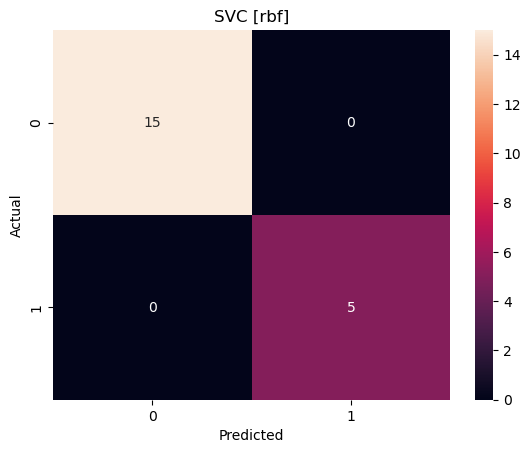

In [37]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True
).set(title='SVC [rbf]')

plt.show()

In [39]:
model = SVC(
    kernel='linear',
    random_state=0
)

model.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [41]:
svc_prediction = model.predict(X_test)

print("svc_prediction : ", svc_prediction)

svc_prediction :  [0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0]


In [43]:
conf_mat = metrics.confusion_matrix(
    y_test,
    svc_prediction
)

print("SVC [ kernel - linear ]")
print("Confusion Matrix : \n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svc_prediction
)

print("Accuracy Score : ", accuracy_score)

print(
    "Accuracy in Percentage : ",
    int(accuracy_score * 100),
    "%"
)

print(
    metrics.classification_report(
        svc_prediction,
        y_test
    )
)

SVC [ kernel - linear ]
Confusion Matrix : 
 [[15  0]
 [ 0  5]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



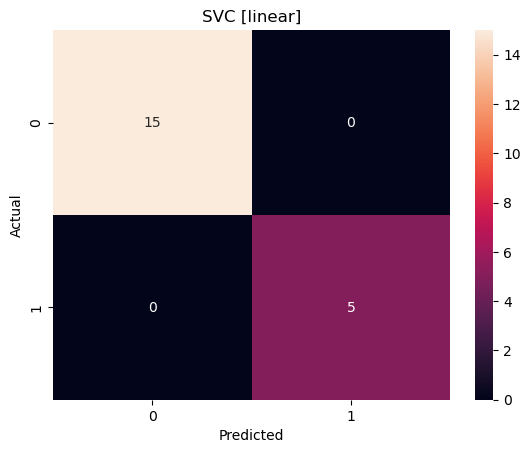

In [45]:
conf_mat = pd.crosstab(
    y_test,
    svc_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True
).set(title='SVC [linear]')

plt.show()